In [1]:
from combine_data import combine_data
from datetime import datetime

from hamiltonian.base import HamiltonianParameters
from misc import data_folder
from solver.circuits import rebuild_ansatz
import h5py
from plotter import ResultLoader
from matplotlib import pyplot as plt
from numpyencoder import NumpyEncoder
import json
from misc import plots_folder
from pathlib import Path

In [2]:
output_filename = plots_folder
output_filename += datetime.now().strftime('%Y-%m-%U')  #datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
Path(output_filename).mkdir(parents=True, exist_ok=True)  #todo
output_filename += "/"
output_filename

'results/plots/2025-09-35/'

In [3]:
combine_data()

-----Combining data-----
Found uncombined file 2025-09-35-23114898.hdf5
Skipping combined file 2025-08-34.hdf5
Skipping combined file 2025-09-35.hdf5
Found uncombined file 2025-09-35-23114900.hdf5
Found uncombined file 2025-09-35-23114899.hdf5
Skipping combined file 2025-08-33.hdf5
Found uncombined file 2025-09-35-23116296.hdf5
Linking results/data/2025-09-35-23114898.hdf5 (1.06 GB) to results/data/2025-09-35.hdf5 (0.27 GB)
Linking results/data/2025-09-35-23114900.hdf5 (0.44 GB) to results/data/2025-09-35.hdf5 (0.27 GB)
Linking results/data/2025-09-35-23114899.hdf5 (0.35 GB) to results/data/2025-09-35.hdf5 (0.27 GB)
Linking results/data/2025-09-35-23116296.hdf5 (0.28 GB) to results/data/2025-09-35.hdf5 (0.27 GB)
-----Finished combining data-----


In [4]:
h5_file = f"{data_folder}{datetime.now().strftime('%Y-%m-%U')}.hdf5"
h5_file

'results/data/2025-09-35.hdf5'

In [5]:
global_info_dict = {}
with h5py.File(h5_file, "r") as f:
    for key, value in f.items():
        loader = ResultLoader(value)
        name, info_dict = loader.info_dict({})
        global_info_dict[name] = info_dict
with open(f"{output_filename}info.json", "w") as finfo:
    json.dump(global_info_dict, finfo, sort_keys=True, indent=4, cls=NumpyEncoder)

In [6]:
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
    vqe_1_loader = ResultLoader(f["2025-09-02_17-46-07"])
    vqe_1_energy, vqe_1_mass = vqe_1_loader.get_energy_mass({})
    vqe_2_loader = ResultLoader(f["2025-09-03_11-10-56"])
    vqe_2_energy, vqe_2_mass = vqe_2_loader.get_energy_mass({})
    vqe_3_loader = ResultLoader(f["2025-09-03_11-11-36"])
    vqe_3_energy, vqe_3_mass = vqe_3_loader.get_energy_mass({})
    vqe_4_loader = ResultLoader(f["2025-09-03_11-12-33"])
    vqe_4_energy, vqe_4_mass = vqe_4_loader.get_energy_mass({})

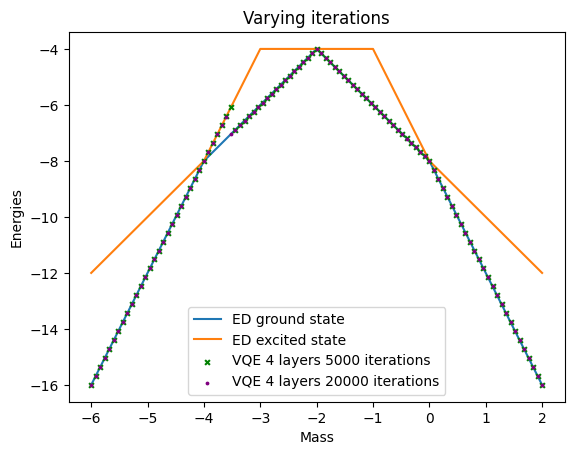

In [7]:
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(vqe_1_mass, vqe_1_energy, label="VQE 4 layers 5000 iterations", marker='x', s=12, color='green')
ax.scatter(vqe_2_mass, vqe_2_energy, label="VQE 4 layers 20000 iterations", marker='.', s=12, color='purple')
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying iterations")
ax.legend()
fig.savefig(f"{output_filename}varying_iterations.png")
fig.savefig(f"{output_filename}varying_iterations.pdf")

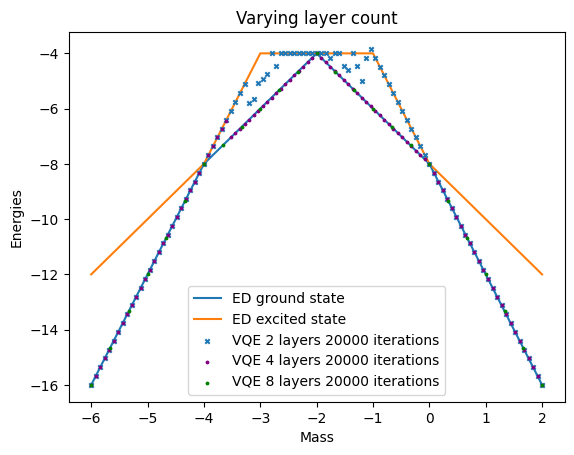

In [8]:
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED excited state", zorder=-1)
ax.scatter(vqe_3_mass, vqe_3_energy, label="VQE 2 layers 20000 iterations", marker='x', s=10)
ax.scatter(vqe_2_mass, vqe_2_energy, label="VQE 4 layers 20000 iterations", marker='.', color='purple', s=12)
ax.scatter(vqe_4_mass, vqe_4_energy, label="VQE 8 layers 20000 iterations", marker='.', color='green', s=12)
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Varying layer count")
ax.legend()
fig.savefig(f"{output_filename}varying_layer_count.png")
fig.savefig(f"{output_filename}varying_layer_count.pdf")

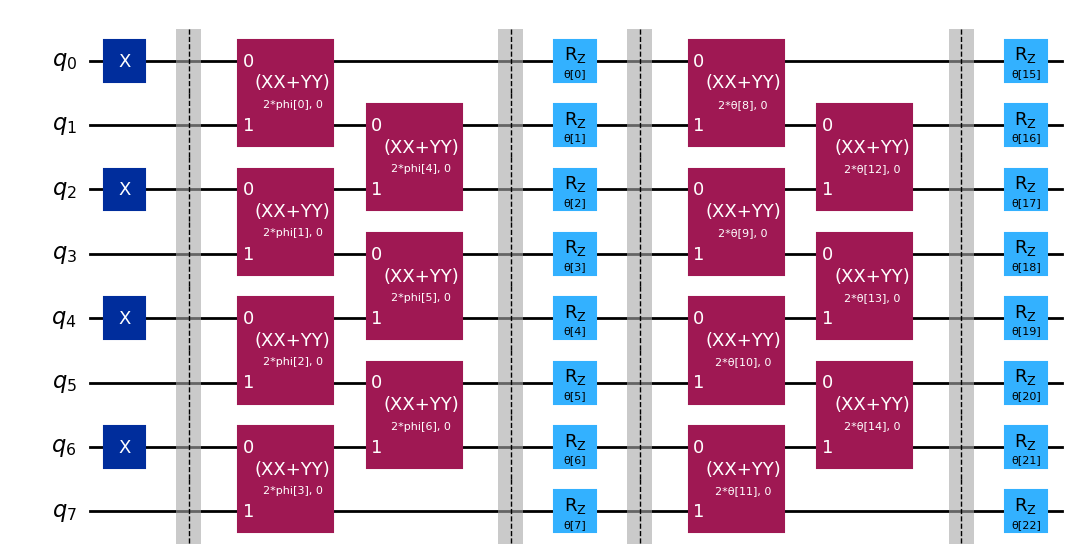

In [9]:
with h5py.File(h5_file, "r") as f:
    circuit = rebuild_ansatz(f["2025-09-03_11-10-56"])
    circuit = rebuild_ansatz(f["2025-09-03_11-11-36"])
    # circuit = rebuild_ansatz(f["2025-09-03_11-12-33"])
circuit.full_ansatz.draw("mpl", filename=f"{output_filename}circuit-2-layer.pdf")

-6.0
-5.2
-4.4
-3.6
-2.8
-2.0
-1.2000000000000002
-0.39999999999999947
0.40000000000000036
1.2000000000000002


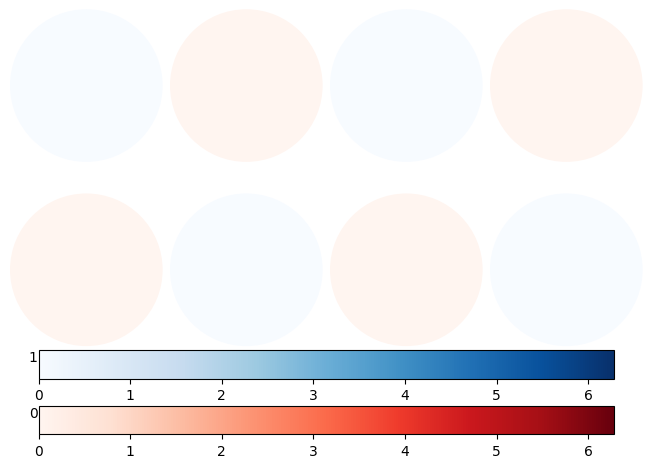

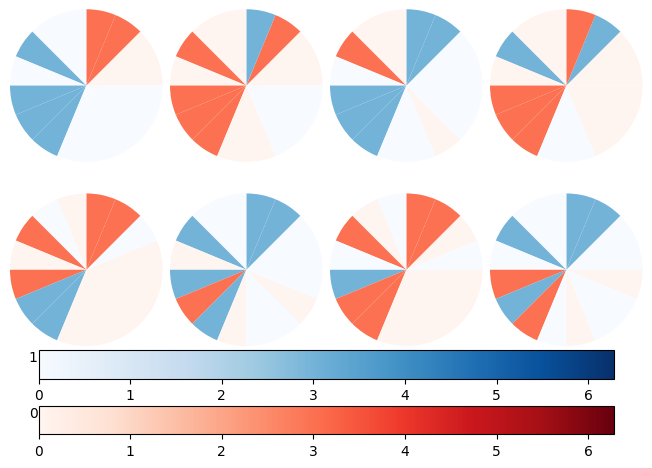

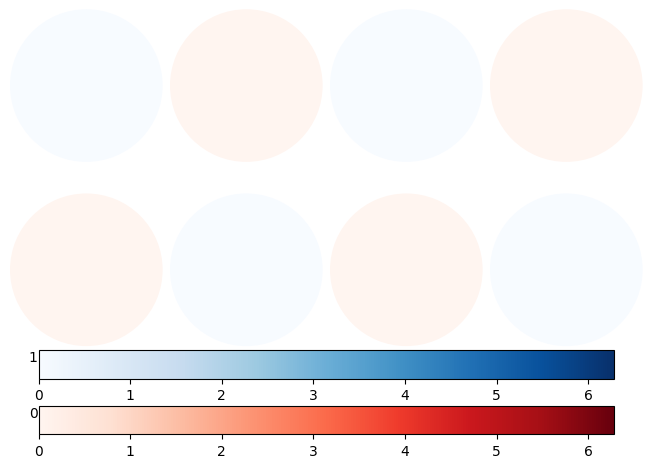

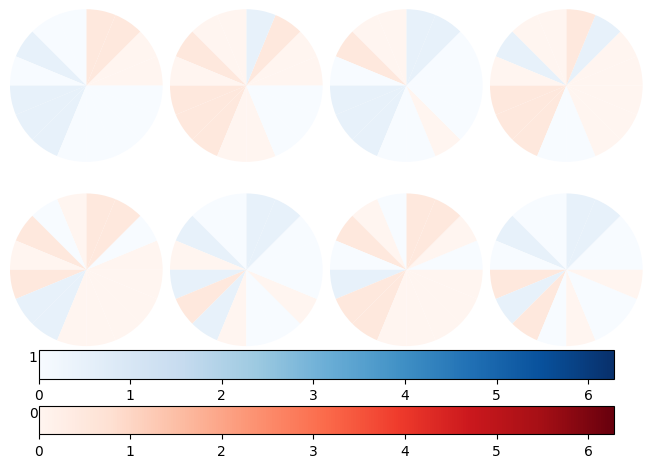

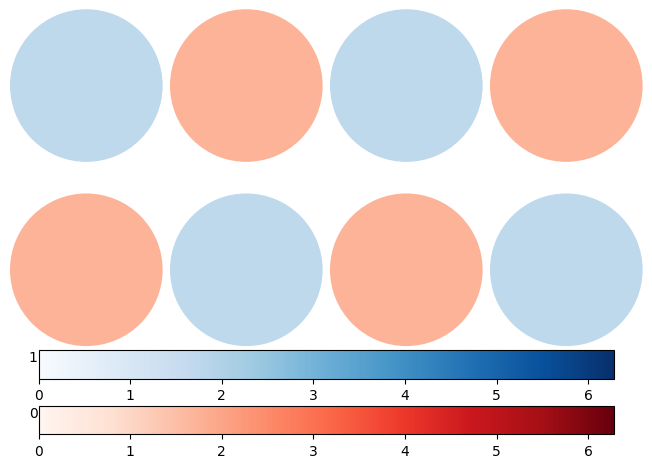

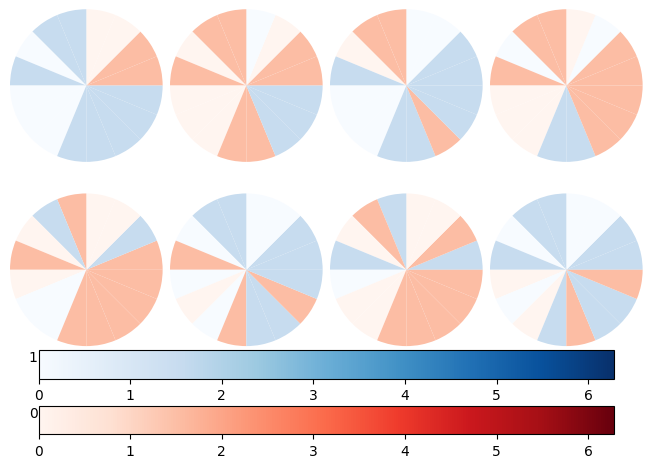

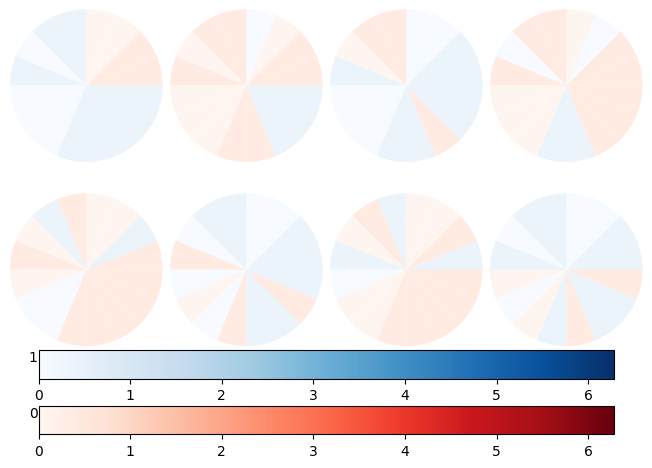

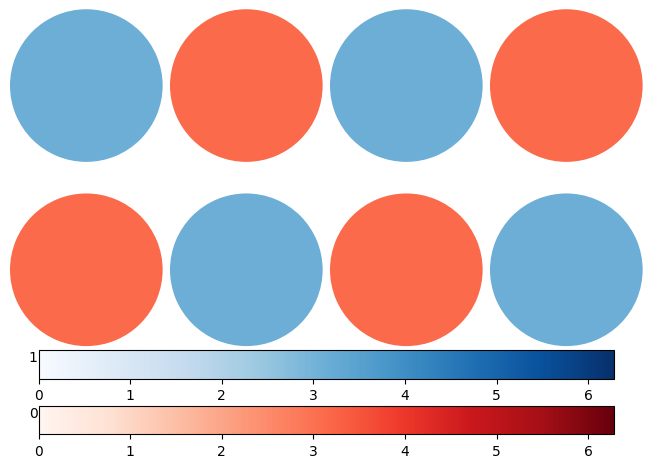

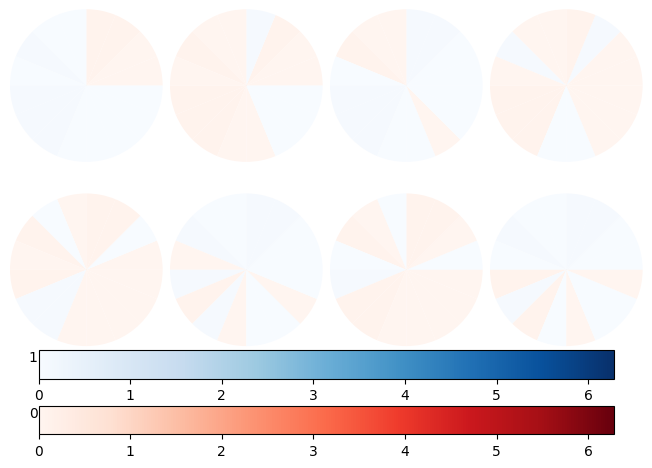

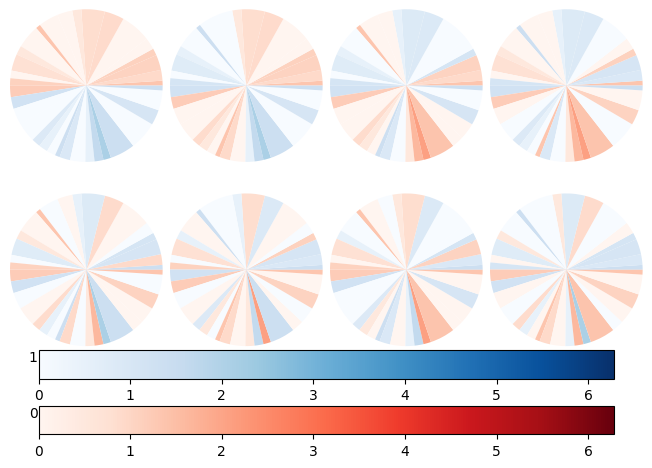

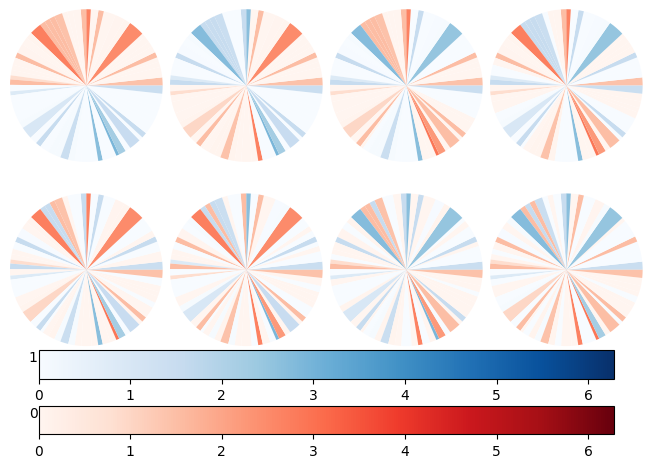

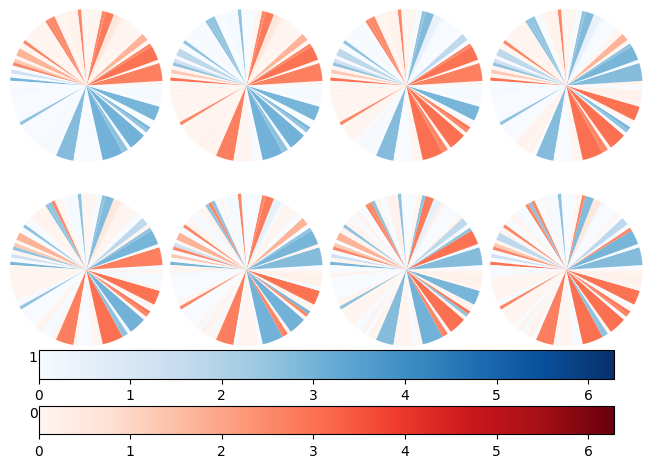

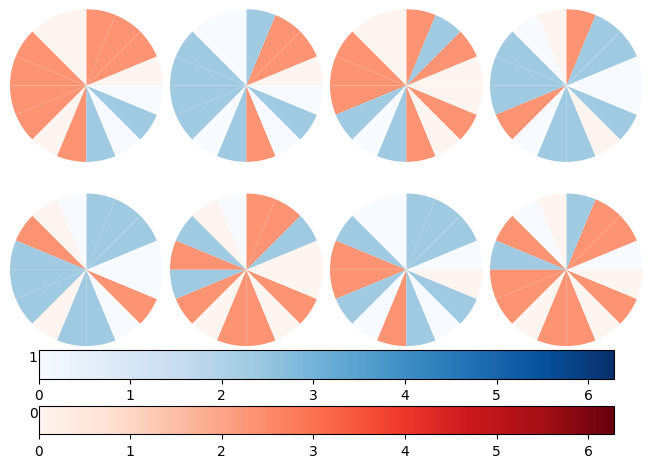

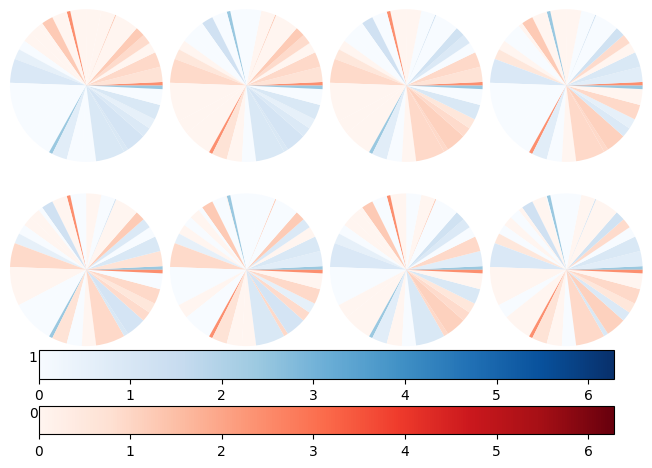

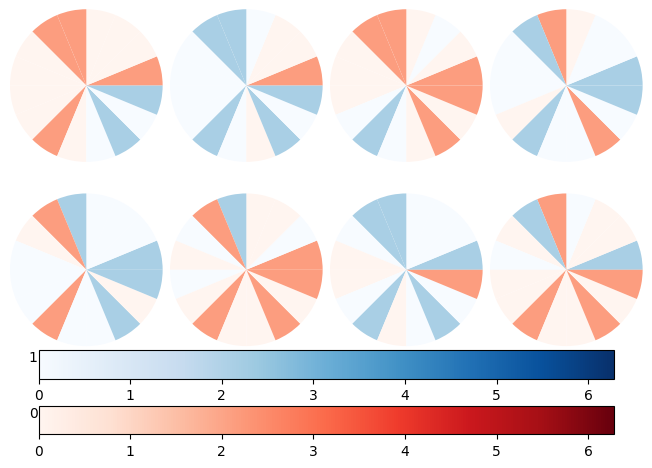

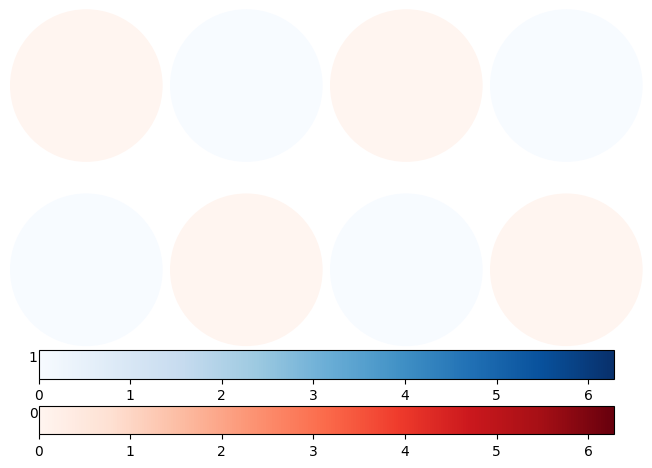

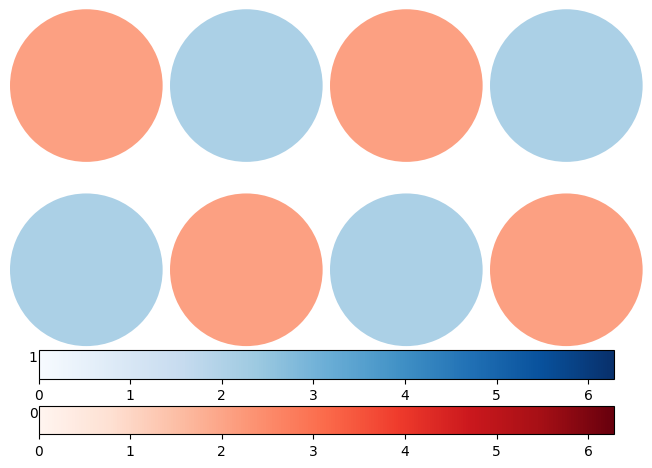

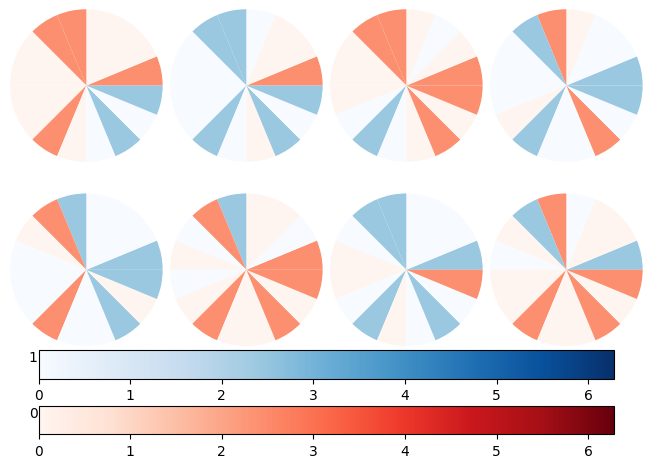

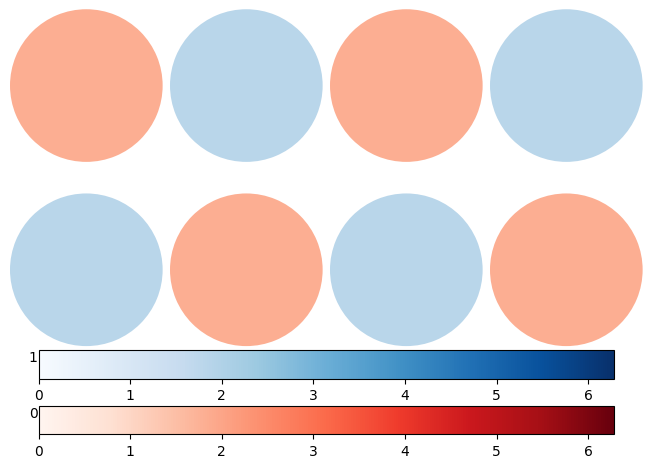

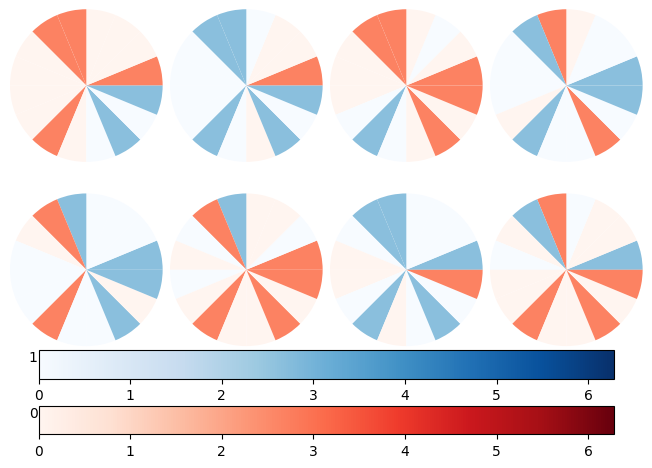

In [10]:
plt.rcParams['figure.constrained_layout.use'] = True
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    for pos in range(0,1000,100):
        print(ed_mass[pos])
        gs_fig = ed_loader.plot_ground_state({HamiltonianParameters.Mass:pos})
        gs_fig.savefig(f"{output_filename}gs_m_{ed_mass[pos]:.2f}.png")
        es_fig = ed_loader.plot_excited_state({HamiltonianParameters.Mass:pos})
        es_fig.savefig(f"{output_filename}es_m_{ed_mass[pos]:.2f}.png")